In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer,InputExample,losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,classification_report
from sklearn.metrics.pairwise import cosine_similarity
import json,warnings
warnings.filterwarnings('ignore')
print('Libraries imported')



Libraries imported


/tmp/ipykernel_1523/3748353663.py:5: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer,InputExample,losses
/tmp/ipykernel_1523/3748353663.py:6: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator


In [ ]:
df=pd.read_csv('cleaned_resumeJD_pairs.csv')
print(f"Loaded:{len(df)}pairs")
print(f"\nLabel distribution:")
print(df['match_label'].value_counts())
# print(f"\nScore range:{df["match_score"].min()}")
df.head(3)

Loaded:19pairs

Label distribution:
match_label
medium match    8
high match      8
low match       3
Name: count, dtype: int64


,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,match_label,match_label_lower,resume_len,jd_len
0,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.75,medium match,medium match,43,43
1,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.65,medium match,medium match,30,30
2,NaN,"To secure an IT specialist, desktop support, n...","['Microsoft Applications', 'Network Security',...","['Glen Oaks High School', 'Glen Oaks High Scho...","['Bachelor Degree', 'Associate Degree']","[None, None]","[None, None]","[None, None]",['Electronics and Communications Engineering T...,"['N/A', 'Company Name', 'Company Name']",...,Bachelors or Masters degree in Computer Scienc...,NaN,NaN,Machine Learning Design\nData Analysis\nModel ...,Python\nR or Java\nTensorFlow\nPyTorch\nScikit...,0.85,high match,high match,20,20


In [ ]:
import pandas as pd
df=pd.read_csv('cleaned_resumeJD_pairs.csv')
from sklearn.model_selection import train_test_split
train_df,temp_df=train_test_split(df,test_size=0.3,random_state=42,stratify=df['match_label'])
val_df,test_df=train_test_split(temp_df,test_size=0.5,random_state=42)
print(f"Train size:{len(train_df)}pairs")
print(f"Validation:{len(val_df)}pairs")
print(f"Test:{len(test_df)}pairs")
for name,split in[('Train',train_df),('Validation',val_df),('Test',test_df)]:
    print(f"\n{name} label dist:{split['match_label'].value_counts()}")

Train size:13pairs
Validation:3pairs
Test:3pairs

Train label dist:match_label
medium match    6
high match      5
low match       2
Name: count, dtype: int64

Validation label dist:match_label
medium match    1
low match       1
high match      1
Name: count, dtype: int64

Test label dist:match_label
high match      2
medium match    1
Name: count, dtype: int64


In [ ]:
label_mapping = {'low match': 0.0, 'medium match': 0.5, 'high match': 1.0}

train_examples=[
    InputExample(texts=[str(row['career_objective']), str(row['responsibilities.1'])], label=label_mapping[row['match_label']])
    for _,row in train_df.iterrows()
]

val_examples=[
    InputExample(texts=[str(row['career_objective']), str(row['responsibilities.1'])], label=label_mapping[row['match_label']])
    for _,row in val_df.iterrows()
]

print(f'Train examples:{len(train_examples)}')
print(f'Val examples:{len(val_examples)}')
print(f'\nSample InputExample:')
print(f'text 1(resume):{train_examples[0].texts[0]}')
print(f'text 2(JD):{train_examples[0].texts[1]}')
print(f'label:{train_examples[0].label}')

Train examples:13
Val examples:3

Sample InputExample:
text 1(resume):To design, develop and manage products in the field of consumer electronics devices, networking protocols, internet applications and connected devices. Vision to create personalized experiences based on machine learning.
text 2(JD):15+ Years Banking Experience
Audit/Inspection/ICC Leadership
Internal Audit & Compliance
Risk-Based Operational Reviews
System-Based Audit Expertise
Knowledge of Bangladeshi Laws
label:0.5


In [ ]:
print('loading base bert model')
base_model=SentenceTransformer('all-mpnet-base-v2')
print('model loaded successfully')


loading base bert model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

model loaded successfully


In [ ]:
print('Evaluating base model on test set...')

base_preds=[]
for _,row in test_df.iterrows():
  emb1=base_model.encode(str(row['career_objective']))
  emb2=base_model.encode(str(row['responsibilities.1']))
  sim=cosine_similarity([emb1],[emb2])[0][0]
  base_preds.append(float(sim))

base_mae=mean_absolute_error(test_df['matched_score'], base_preds)
base_rmse=np.sqrt(mean_squared_error(test_df['matched_score'], base_preds))

print(f'\nBase Model-Test Set Performance')
print(f'MAE:{base_mae:.4f}')
print(f'RMSE:{base_rmse:.4f}')
print()
print('Goal:fine-tuning should reduce MAE ')

Evaluating base model on test set...

Base Model-Test Set Performance
MAE:0.5808
RMSE:0.6026

Goal:fine-tuning should reduce MAE 


In [ ]:
model=SentenceTransformer('all-mpnet-base-v2')
train_dataloader=DataLoader(train_examples,shuffle=True,batch_size=16)
train_loss=losses.CosineSimilarityLoss(model)
evaluator=EmbeddingSimilarityEvaluator.from_input_examples(val_examples,name='ats-val')

print('Training setup ready.')
print(f'Batch size:16')
print(f'Train pairs:{len(train_examples)}')
print(f'Steps/epoch:{len(train_dataloader)}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Training setup ready.
Batch size:16
Train pairs:13
Steps/epoch:1


In [ ]:
total_steps=len(train_dataloader)*10
warmup_steps=int(total_steps*0.1)

print(f'Total steps:{total_steps}')
print(f'Warmup steps:{warmup_steps}')
print(f'\nStarting fine-tuning....\n')

model.fit(
    train_objectives=[(train_dataloader,train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),
    warmup_steps=warmup_steps,
    output_path='models/finetuned-bert',
    save_best_model=True,
    use_amp=True,
    show_progress_bar=True

)

print('\n FINE TUNING COMPLETE!!')

Total steps:10
Warmup steps:1

Starting fine-tuning....



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
1,No log,No log,0.441862,0.500000
2,No log,No log,0.441862,0.500000
3,No log,No log,0.441862,0.500000
4,No log,No log,0.441862,0.500000
5,No log,No log,0.441862,0.500000
6,No log,No log,0.441862,0.500000
7,No log,No log,0.441862,0.500000
8,No log,No log,0.441862,0.500000
9,No log,No log,0.441862,0.500000
10,No log,No log,0.441862,0.500000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


 FINE TUNING COMPLETE!!


In [ ]:
finetuned_model=SentenceTransformer('models/finetuned-bert')
print('Fine-tuned model loaded.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded.


In [ ]:
ft_preds=[]
for _,row in test_df.iterrows():
  emb1=finetuned_model.encode(row['career_objective'])
  emb2=finetuned_model.encode(row['responsibilities.1'])
  sim=cosine_similarity([emb1],[emb2])[0][0]
  ft_preds.append(float(sim))

ft_mae=mean_absolute_error(test_df['matched_score'], ft_preds)
ft_rmse=np.sqrt(mean_squared_error(test_df['matched_score'], ft_preds))

print(f'\nFine-Tuned Model-Test Set Performance')
print(f'MAE:{ft_mae:.4f}')
print(f'RMSE:{ft_rmse:.4}')


Fine-Tuned Model-Test Set Performance
MAE:0.5808
RMSE:0.6026


In [ ]:
print('='*50)
print('MODEL PERFORMANCE')
print('='*50)
print(f'Base MAE:{base_mae:.4f}')
print(f'Fine-Tuned MAE:{ft_mae:.4f}')
print(f'Improvement:{(base_mae-ft_mae)/base_mae*100:.2f}%')
print('='*50)

MODEL PERFORMANCE
Base MAE:0.5808
Fine-Tuned MAE:0.5808
Improvement:0.00%


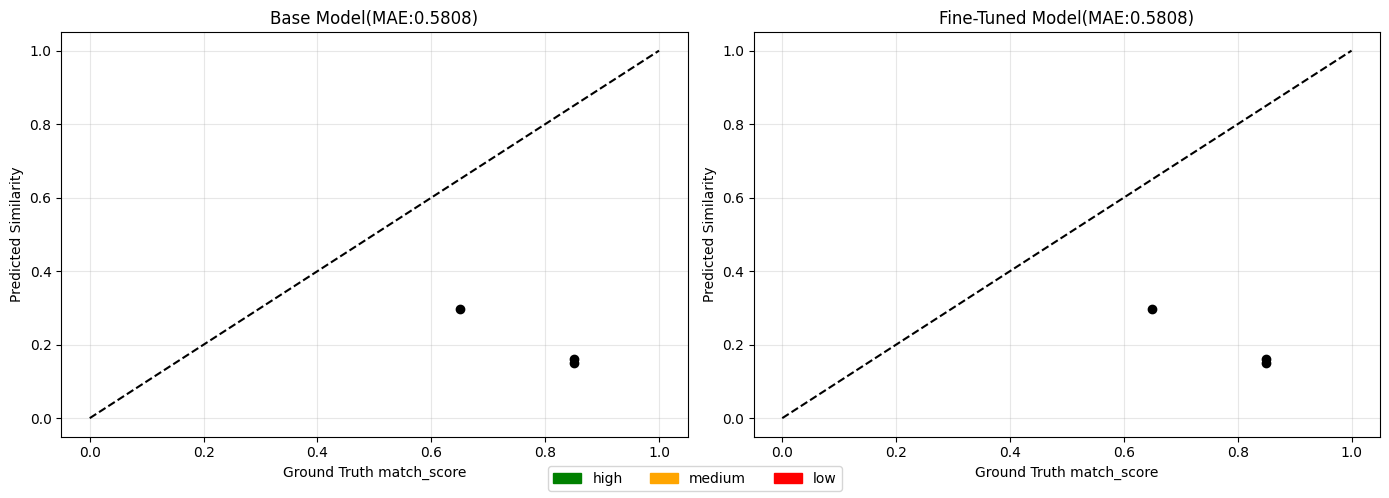

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
colors=test_df['match_label'].map({'low':'red', 'medium':'orange', 'high':'green'})

for ax,preds,title,mae in[
    (axes[0],base_preds,'Base Model',base_mae),
    (axes[1],ft_preds,'Fine-Tuned Model',ft_mae)
]:
  ax.scatter(test_df['matched_score'],preds,color=colors)
  ax.plot([0,1],[0,1],'k--',label='Perfect')
  ax.set_xlabel('Ground Truth match_score')
  ax.set_ylabel('Predicted Similarity')
  ax.set_title(f'{title}(MAE:{mae:.4f})')
  ax.grid(True,alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color='green',label='high'),
    Patch(color='orange',label='medium'),
    Patch(color='red',label='low')
],loc='lower center',ncol=3)
plt.tight_layout()
plt.show()

In [ ]:
metadata={
    'base_model':'all-mpnet-base-v2',
    'dataset':'merged_dataset_clean.',
    'total_pairs':len(df),
    'train_pairs':len(train_df),
    'val_pairs':len(val_df),
    'test_pairs':len(test_df),
    'epochs':10,
    'batch_size':16,
    'base_mae':round(float(base_mae),4),
    'finetuned_mae':round(float(ft_mae),4),
    'improvement_pct':round((base_mae-ft_mae)/base_mae*100,2)
}

with open('models/finetuned-bert/metadata.json','w') as f:
  json.dump(metadata,f,indent=4)

print('Saved:models/finetuned-bert/')
print(json.dumps(metadata,indent=2))

Saved:models/finetuned-bert/
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.",
  "total_pairs": 19,
  "train_pairs": 13,
  "val_pairs": 3,
  "test_pairs": 3,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.5808,
  "finetuned_mae": 0.5808,
  "improvement_pct": 0.0
}


In [ ]:
def score_resume_against_jd(resume_text,jd_text,model):

  emb_resume=model.encode(resume_text,convert_to_numpy=True)
  emb_jd=model.encode(jd_text,convert_to_numpy=True)
  score=cosine_similarity([emb_resume],[emb_jd])[0][0]
  return float(score)

test_cases=[
    {
        'label':'HIGH match expected',
        'resume':'Senior Python ',
        'jd':'We need a Python',
    },
    {
        'label':'MEDIUM match exp',
        'resume':'Frotened develope',
        'jd':'Full stack engineer needed',
    },
    {
        'label':'LOW match expected',
        'resume':'Executive Chef with 12 years',
        'jd':'Data Scientist with Python',
    },
]

print('Production Pipeline Test')
print('='*60)
for case in test_cases:
  score=score_resume_against_jd(case['resume'],case['jd'],finetuned_model)
  # Assign label based on score thresholds, assuming 0.0=low, 0.5=medium, 1.0=high
  if score >= 0.75:
      label = 'HIGH'
  elif score >= 0.25:
      label = 'MEDIUM'
  else:
      label = 'LOW'

  print(f"\n{case['label']}")
  print(f"Predicted score:{score:.4f}")
  print(f"Predicted label:{label}")

Production Pipeline Test

HIGH match expected
Predicted score:0.5722
Predicted label:MEDIUM

MEDIUM match exp
Predicted score:0.1579
Predicted label:LOW

LOW match expected
Predicted score:0.1000
Predicted label:LOW
